<a href="https://colab.research.google.com/github/LayanaKooli/Amazon-Customer-Review/blob/main/Amazon_Consumer_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚛ Amazon Product Review Sentiment Analysis
Binary sentiment classification (Positive/Negative) from review text, using TF-IDF
features and classical ML models.

## ♦ Libraries

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## ♦ Load Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'consumer-reviews-of-amazon-products' dataset.
Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products


In [3]:
import os
print(os.listdir(path))

['Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv', '1429_1.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv']


## ♦ Dataset Overview

In [4]:
df_amazon = pd.read_csv(path + '/' + 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv')
df_amazon.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [5]:
df_amazon["name"].nunique()

65

In [6]:
df_amazon.shape

(28332, 24)

Inference :

* From head(), 1st 5 rows in the dataset shows : 5 different reviews of the same product.

* Denormalized Table : One row per review, but product-level info like brand and category is copied onto every review of that product instead of stored once, which is why 65 products produce 27,126 rows.

* Changes across all 1st 5 rows

    * "reviews.text",

    * "reviews.title",

    * "reviews.username"

In [7]:
df_amazon['name'].value_counts().head(10)

# Why check this, before modeling?
# If one product massively dominates, the model risks learning "words specific to that one product" rather than general sentiment language.

,count
name,
AmazonBasics AAA Performance Alkaline Batteries (36 Count),8343
AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary,3728
"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers",2443
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Black",2370
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Pink Kid-Proof Case",1676
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Blue Kid-Proof Case",1425
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",1212
"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black",1024
"Fire Tablet with Alexa, 7 Display, 16 GB, Blue - with Special Offers",987


**Inference:**

* 10 of 65 products account for 85% of all reviews (24,091/28,332); the single top product (AAA batteries) alone is 29%.

* Confirms the model risks learning product-specific vocabulary rather than general sentiment language.

In [8]:
(df_amazon['reviews.rating'].value_counts(normalize=True).sort_index() * 100).round(1)

,proportion
reviews.rating,
1,3.4
2,2.2
3,4.3
4,19.9
5,70.2


In [9]:
df_amazon.tail()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
28327,AVqkIhxunnc1JgDc3kg_,2017-03-06T14:59:43Z,2019-02-23T02:49:38Z,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",B018T075DC,Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,"amazon/b018t075dc,firehd8tabletwithalexa8hddis...",...,NaN,True,NaN,0.0,5,http://reviews.bestbuy.com/3545/5620410/review...,I got 2 of these for my 8 yr old twins. My 11 ...,Xmas gift,Mom2twinsplus1,http://reviews.bestbuy.com/3545/5620410/review...
28328,AVqkIhxunnc1JgDc3kg_,2017-03-06T14:59:43Z,2019-02-23T02:49:38Z,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",B018T075DC,Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,"amazon/b018t075dc,firehd8tabletwithalexa8hddis...",...,NaN,True,NaN,0.0,4,http://reviews.bestbuy.com/3545/5620410/review...,I bought this for my niece for a Christmas gif...,yes it is a great tablet.,fireman21,http://reviews.bestbuy.com/3545/5620410/review...
28329,AVqkIhxunnc1JgDc3kg_,2017-03-06T14:59:43Z,2019-02-23T02:49:38Z,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",B018T075DC,Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,"amazon/b018t075dc,firehd8tabletwithalexa8hddis...",...,NaN,True,NaN,0.0,5,http://reviews.bestbuy.com/3545/5620410/review...,"Very nice for light internet browsing, keeping...",You get a lot for the price!,suzannalicious,http://reviews.bestbuy.com/3545/5620410/review...
28330,AVqkIhxunnc1JgDc3kg_,2017-03-06T14:59:43Z,2019-02-23T02:49:38Z,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",B018T075DC,Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,"amazon/b018t075dc,firehd8tabletwithalexa8hddis...",...,NaN,True,NaN,0.0,5,http://reviews.bestbuy.com/3545/5620410/review...,This Tablet does absolutely everything I want!...,You get the entire World for less than $100!,SandyJ,http://reviews.bestbuy.com/3545/5620410/review...
28331,AVqkIhxunnc1JgDc3kg_,2017-03-06T14:59:43Z,2019-02-23T02:49:38Z,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",B018T075DC,Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,"amazon/b018t075dc,firehd8tabletwithalexa8hddis...",...,NaN,True,NaN,0.0,4,http://reviews.bestbuy.com/3545/5620410/review...,"At ninety dollars, the expectionations are low...",You get what your paying for,Hung,http://reviews.bestbuy.com/3545/5620410/review...


**Inference:**

* tail() shows Alexa/Fire tablet products, different from head()'s batteries.

* Row counts from value_counts() exactly match what head()/tail() show - proof the dataset is sorted by product, not shuffled.

* This is why shuffle = True in the later train/test split is a MUST !

In [10]:
pos_words = ['love', 'great', 'excellent', 'good', 'best', 'perfect', 'happy', 'awesome', 'amazing', 'nice']
neg_words = ['bad', 'terrible', 'worst', 'broke', 'broken', 'disappointed', 'waste', 'poor', 'hate', 'useless']

def text_polarity(text):
    t = str(text).lower()
    p = sum(t.count(w) for w in pos_words)
    n = sum(t.count(w) for w in neg_words)
    if p > n: return 'text_reads_positive'
    elif n > p: return 'text_reads_negative'
    else: return 'text_reads_neutral'

df_amazon['text_polarity'] = df_amazon['reviews.text'].apply(text_polarity)
pd.crosstab(df_amazon['reviews.rating'], df_amazon['text_polarity'], normalize='index').round(3) * 100

text_polarity,text_reads_negative,text_reads_neutral,text_reads_positive
reviews.rating,,,
1,24.7,62.2,13.2
2,11.7,60.4,27.9
3,3.5,56.6,39.9
4,1.3,32.0,66.7
5,0.6,27.2,72.2


**Inference:**

* Negative-reading text drops as rating goes up (24.7% at 1-star to 0.6% at 5-star).

* Positive-reading text rises the same way (13.2% to 72.2%).

* 3-star is the only rating where no single direction wins - positive, neutral and negative are all close together.

* This word count can't detect negation, so "not good" gets counted as positive by mistake.

* The positive% at low ratings is probably too high because of this.

## ♦ Label Construction

In [11]:
df_amazon = df_amazon[df_amazon['reviews.rating'] != 3].copy()
df_amazon['sentiment'] = df_amazon['reviews.rating'].apply(lambda r: 'Positive' if r>=4 else 'Negative')
df_amazon['sentiment'].value_counts()

,count
sentiment,
Positive,25545
Negative,1581


In [12]:
both = df_amazon[df_amazon['reviews.doRecommend'].notna()]
agree = (both['sentiment'] == both['reviews.doRecommend'].map({True:'Positive', False:'Negative'})).mean()
agree

np.float64(0.9926751798794322)

**Inference:**

* Rating and doRecommend agree 99.27% of the time where both exist, near total redundancy.

* Combined with doRecommend being 43% missing where rating is 100% complete, rating is used as the sole target.

In [13]:
avg_helpful = df_amazon.groupby('sentiment')['reviews.numHelpful'].mean()
avg_helpful

,reviews.numHelpful
sentiment,
Negative,3.455607
Positive,0.456947


In [14]:
avg_helpful['Negative'] / avg_helpful['Positive']

np.float64(7.562380829893477)

**Inference:**

* Negative reviews average 7.5x more helpful-votes than Positive ones - a real, strong relationship, not a weak one.

* Excluded anyway: numHelpful only accumulates after a review is published and others react to it.

* Hence, it doesn't exist at the moment a new review is written. Real signal, but leakage, not usable.

In [15]:
encoded = LabelEncoder().fit_transform(df_amazon['reviews.username'].astype(str))
mutual_info_classif(encoded.reshape(-1,1), df_amazon['sentiment'], discrete_features=True, random_state=42)

array([0.1939897])

**Inference:**

* MI = 0.194 is ~20x higher than any product-metadata feature tested (brand/name/manufacturer/categories all ~0.01).

* Excluded despite the high score: 57.5% of usernames are unique (15,598/27,126).

* This reflects the model memorizing specific repeat reviewer's known rating history, not genuine language signal.

## ♦ Text Cleaning

In [16]:
stop_words = set(stopwords.words('english'))
stop_words = stop_words - {'not', 'no', 'nor'}   # keep negation - removing these flips meaning (e.g. "not good" -> "good")
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(words)

df_amazon['clean_text'] = df_amazon['reviews.text'].apply(clean_text)
df_amazon[['reviews.text', 'clean_text']].head()

,reviews.text,clean_text
1,Bulk is always the less expensive way to go fo...,bulk always less expensive way go product like
2,Well they are not Duracell but for the price i...,well not duracell price happy
3,Seem to work as well as name brand batteries a...,seem work well name brand battery much better ...
4,These batteries are very long lasting the pric...,battery long lasting price great
5,Bought a lot of batteries for Christmas and th...,bought lot battery christmas amazonbasics cell...


## ♦ Exploratory Data Analysis

In [17]:
# Display the names of all columns
print("\nColumn names : ",df_amazon.columns)


Column names :  Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs',
       'text_polarity', 'sentiment', 'clean_text'],
      dtype='object')


## Dataset Overview — Column Meanings

**The rule:**
* no `reviews.` prefix ---> describes the PRODUCT, repeats across every review of that product (denormalized table).

* Has `reviews.` prefix ---> describes THIS ONE specific review.
_________________________________________________________________________________________________________________________________________________________________________
                            Product-level                         |                          Review-level
__________________________________________________________________________________________________________________________________________________________________________
    ◼ id                 =   Datafiniti's identifier code for the    ◼ reviews.date        =  when the reviewer actually wrote it
                              product (65 unique, matches name)
    ◼ dateAdded          =   when Datafiniti's database first saved  ◼ reviews.dateSeen    =  when Datafiniti's scraper observed
                              this listing                                                     the review online
    ◼ dateUpdated        =   when Datafiniti's database last         ◼ reviews.didPurchase =  verified purchase flag
                              refreshed this listing                                           (real python boolean value)
    ◼ name               =   the product's actual title              ◼ reviews.doRecommend =  would-recommend flag
    ◼ asins              =   Amazon's own product code (ASIN)                                  (real python boolean value)
    ◼ brand              =   the marketing name customers shop by    ◼ reviews.id          =  the review's own identifier
    ◼ categories         =   every tag the listing was filed under,                           (not the same as plain id, which is
                              full detail, comma-separated.                                    product-level) .
                              (e.g. 28 tags for one Fire TV Stick,                             A database record number (208530447)
                              including scraping noise like                                    , not an IP address
                              "TVs Entertainment xbqxrzdteyyb")
    ◼ primaryCategories  =   Datafiniti's simplified single-label                              
                              version of categories ("Electronics")   ◼ reviews.numHelpful  =  helpful-vote count (
    ◼ imageURLs          =   link(s) to the product photo                                      only exists after publication,
    ◼ keys               =   Datafiniti's internal matching key,                               leakage, not usable signal, even
                              used to recognize the same product                               though a real 7.5x difference exists
                              across sites                                                     by sentiment)
    ◼ manufacturer       =   the company that physically makes the   ◼ reviews.rating      =  the 1-5 star score; source of the
                              product                                                          label, not a feature
    ◼ manufacturerNumber =   the manufacturer's own internal         ◼ reviews.sourceURLs  =  the URL where this specific review
                              catalog/model number                                             was found
    ◼ sourceURLs         =   the URL where the product listing       ◼ reviews.text        =  the review body
                             itself was found. Every site Datafiniti
                             cross-referenced to confirm the product
                             (mostly Amazon links, plus a barcode     ◼ reviews.title       =  the review headline
                             -lookup site)   
                                                                      ◼ reviews.username    =  reviewer's name displayed


In [18]:
# Display information about the dataset
# - Total number of rows and columns
# - Column names
# - Data types of each column
# - Number of non-missing (non-null) values
# It helps identify missing values and understand the dataset structure

df_amazon.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27126 entries, 1 to 28331
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   27126 non-null  object 
 1   dateAdded            27126 non-null  object 
 2   dateUpdated          27126 non-null  object 
 3   name                 27126 non-null  object 
 4   asins                27126 non-null  object 
 5   brand                27126 non-null  object 
 6   categories           27126 non-null  object 
 7   primaryCategories    27126 non-null  object 
 8   imageURLs            27126 non-null  object 
 9   keys                 27126 non-null  object 
 10  manufacturer         27126 non-null  object 
 11  manufacturerNumber   27126 non-null  object 
 12  reviews.date         27126 non-null  object 
 13  reviews.dateSeen     27126 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doRecommend  15427 non-null  obje

## Missing Values - sorted by severity

    ◼ reviews.id            :   28,291 missing (99.9%) - only 41 real values exist, unusable

    ◼ reviews.didPurchase   :   28,323 missing (99.97%) - only 9 real values exist, unusable

    ◼ reviews.doRecommend   :   12,246 missing (43%) - not used as target: on rows where both exist, rating (>=4/<=2) agrees with
                                doRecommend 99.27% of the time. Near-total redundancy, and rating is 100% complete where
                                doRecommend isn't.

    ◼ reviews.numHelpful    :   12,217 missing (43%) - excluded regardless of missingness. A real 7.5x difference exists between
                                classes (avg 3.46 on Negative reviews vs 0.46 on Positive), but it only accumulates AFTER a review
                                is published and other users react to it - doesn't exist at the moment a new review is written.
                                Real signal, but leakage.

    ◼ reviews.username      :   5 missing (0.02%) - irrelevant either way, since username is excluded as a feature entirely
                                (MI=0.194, far higher than any legitimate feature - memorization risk, not genuine signal).
                                No rows are dropped for this.

**No rows are yet dropped anywhere in this project for missingness** = the only two columns actually used (reviews.text, reviews.rating)
                                                                       both have zero missing values.

**Dtypes:**

    ◼ int64    --->   reviews.rating
    ◼ float64  --->   reviews.id, reviews.numHelpful
    ◼ object   --->   remaining 21 columns
NOTE : reviews.rating is the only numeric column still int64 because it's the only one with zero missing values - NaN is itself a float,
so any numeric column with even one gap gets force-upgraded to float64 to hold it.

In [19]:
# Summary statistics for numerical columns
df_amazon.describe()

,reviews.id,reviews.numHelpful,reviews.rating
count,3.900000e+01,15456.000000,27126.000000
mean,1.855467e+08,0.539984,4.581361
std,2.143690e+07,9.529512,0.898087
min,1.116244e+08,0.000000,1.000000
25%,1.843760e+08,0.000000,4.000000
50%,1.885078e+08,0.000000,5.000000
75%,1.989511e+08,0.000000,5.000000
max,2.085304e+08,621.000000,5.000000


In [20]:
df_amazon.isna().sum()

,0
id,0
dateAdded,0
dateUpdated,0
name,0
asins,0
brand,0
categories,0
primaryCategories,0
imageURLs,0
keys,0


In [21]:
df_amazon.duplicated().sum()

np.int64(0)

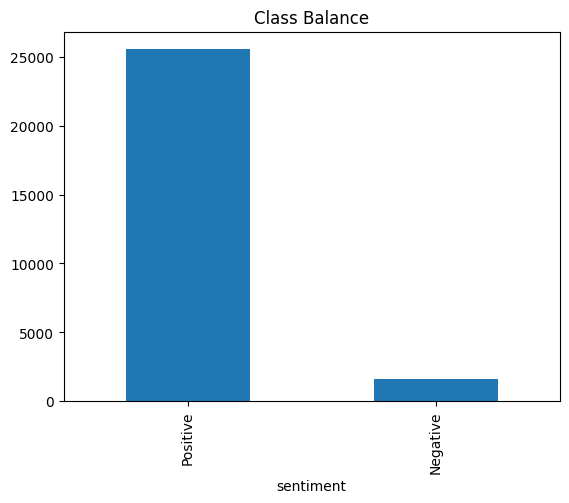

In [22]:
df_amazon['sentiment'].value_counts().plot(kind='bar', title='Class Balance')
plt.show()

**Inference (Class Balance):**

* Positive = 25,545 (94.2%), Negative = 1,581 (5.8%). Severe imbalance, matches the number already found earlier.

* A model that always guesses Positive would score ~94% accuracy while being useless. This is why class_weight='balanced' is needed for every model later.

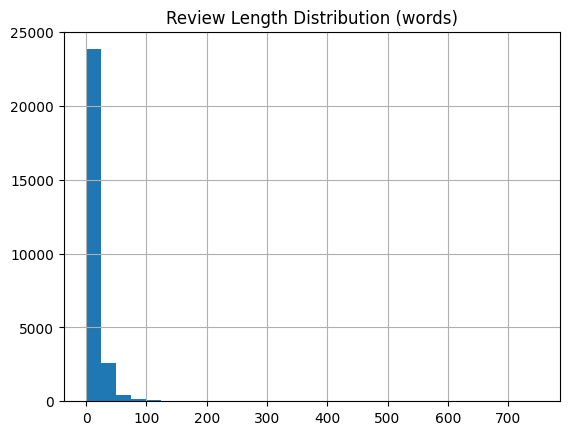

In [23]:
df_amazon['review_length'] = df_amazon['clean_text'].str.split().apply(len)
df_amazon['review_length'].hist(bins=30)
plt.title('Review Length Distribution (words)')
plt.show()

In [24]:
df_amazon['review_length'].describe()

,review_length
count,27126.000000
mean,13.227531
std,18.378280
min,0.000000
25%,5.000000
50%,9.000000
75%,15.000000
max,748.000000


**Inference (Review Length):**

* Mean is 13.2 words, median is 9 words. Mean is higher than median, so it's right-skewed.

* Most reviews are short. 25% of reviews have 5 words or fewer.

* Some reviews have 0 words after cleaning - the text was stopwords or punctuation with nothing left.

* Max is 748 words - one review is a huge outlier compared to the rest.

**Note:**

* review_length and text_polarity are EDA-only columns, used to understand the data.

* Neither is used as a model feature, the model trains on TF-IDF vectors built from clean_text directly.

In [25]:
for sentiment in ['Positive', 'Negative']:
    words = ' '.join(df_amazon[df_amazon['sentiment']==sentiment]['clean_text']).split()
    print(f'Top 10 words - {sentiment}')
    print(Counter(words).most_common(10))
    print()

Top 10 words - Positive
[('great', 9096), ('battery', 8078), ('tablet', 6730), ('love', 5646), ('good', 5353), ('price', 4966), ('use', 3970), ('work', 3427), ('amazon', 3280), ('not', 2982)]

Top 10 words - Negative
[('battery', 1584), ('not', 868), ('last', 441), ('amazon', 408), ('dont', 319), ('one', 288), ('use', 281), ('work', 269), ('time', 258), ('buy', 255)]



**Inference:**

* Positive words: great, battery, tablet, love, good, price.

* Negative words: battery, not, last, amazon, dont, one, use, work, time, buy.

* "not" and "dont" appear only in Negative's 10, confirming the negation fix mattered.

## ♦ Train-Test Split

In [26]:
X = df_amazon['clean_text']
y = df_amazon['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## ♦ TF-IDF Vectorization

In [27]:
tfidf = TfidfVectorizer(max_features = 5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ♦ Model Training

In [28]:
# Dictionary to save modelds
models = {}

## ♦ Logistic Regression

In [31]:
# class_weight='balanced' gives more importance to the minority class
logistic_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Train the model using TF-IDF features
logistic_model.fit(X_train_tfidf, y_train)

# Store the trained model
models['Logistic Regression'] = logistic_model

# Make predictions on the test data
y_pred_lr = logistic_model.predict(X_test_tfidf)

# Display classification report
print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report:

              precision    recall  f1-score   support

    Negative       0.53      0.88      0.66       316
    Positive       0.99      0.95      0.97      5110

    accuracy                           0.95      5426
   macro avg       0.76      0.92      0.82      5426
weighted avg       0.97      0.95      0.95      5426



## ♦ Naive Bayes

In [32]:
# Create Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

# Store the trained model
models['Naive Bayes'] = nb_model

# Make predictions on the test data
y_pred_nb = nb_model.predict(X_test_tfidf)

# Display classification report
print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Classification Report:

              precision    recall  f1-score   support

    Negative       0.93      0.13      0.22       316
    Positive       0.95      1.00      0.97      5110

    accuracy                           0.95      5426
   macro avg       0.94      0.56      0.60      5426
weighted avg       0.95      0.95      0.93      5426



## ♦ Linear SVM

In [33]:
# Create Linear SVM model
# class_weight='balanced' helps handle the severe class imbalance
svm_model = LinearSVC(
    class_weight='balanced',
    random_state=42
)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

# Store the trained model
models['Linear SVM'] = svm_model

# Make predictions on the test data
y_pred_svm = svm_model.predict(X_test_tfidf)

# Display classification report
print("Linear SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

Linear SVM Classification Report:

              precision    recall  f1-score   support

    Negative       0.64      0.83      0.72       316
    Positive       0.99      0.97      0.98      5110

    accuracy                           0.96      5426
   macro avg       0.81      0.90      0.85      5426
weighted avg       0.97      0.96      0.96      5426



## ♦ Model Evaluation

In [34]:
# Function to calculate evaluation metrics
def evaluate_model(model_name, y_test_2, y_pred):

    accuracy = accuracy_score(y_test_2, y_pred)
    precision = precision_score(y_test_2, y_pred, pos_label='Negative')
    recall = recall_score(y_test_2, y_pred, pos_label='Negative')
    f1 = f1_score(y_test_2, y_pred, pos_label='Negative')

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Evaluate each model
results = []

results.append(
    evaluate_model(
        'Logistic Regression',
        y_test,
        y_pred_lr
  ))

results.append(
    evaluate_model(
        'Naive Bayes',
        y_test,
        y_pred_nb
  ))

results.append(
    evaluate_model(
        'Linear SVM',
        y_test,
        y_pred_svm
  ))

# Create a dataframe containing all results
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.947475,0.529524,0.879747,0.661118
1,Naive Bayes,0.948581,0.930233,0.126582,0.222841
2,Linear SVM,0.962588,0.638142,0.825949,0.720000


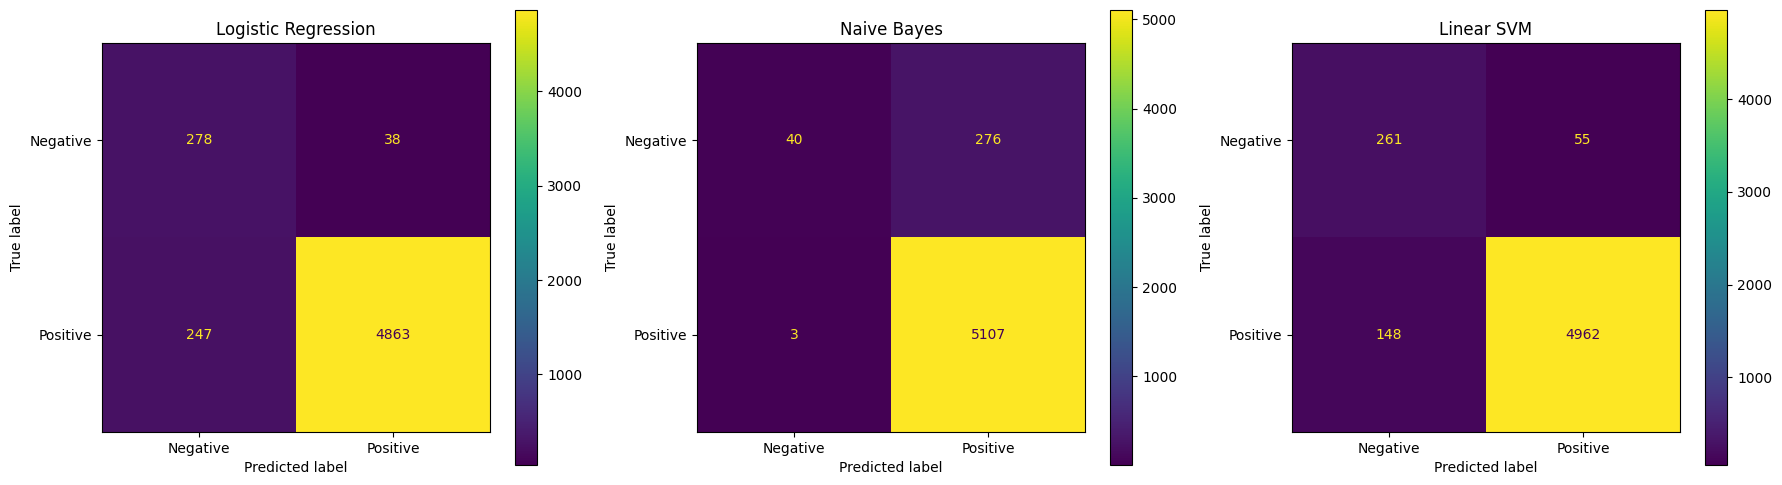

In [35]:
# Create confusion matrices for all models

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    ax=axes[0]
)
axes[0].set_title('Logistic Regression')

# Naive Bayes
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    ax=axes[1]
)
axes[1].set_title('Naive Bayes')

# Linear SVM
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    ax=axes[2]
)
axes[2].set_title('Linear SVM')

plt.tight_layout()
plt.show()

## ♦ Model Comparison

In [36]:
# Set model names as the index
comparison = results_df.set_index('Model')

# Display comparison table
display(comparison.round(4))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.9475,0.5295,0.8797,0.6611
Naive Bayes,0.9486,0.9302,0.1266,0.2228
Linear SVM,0.9626,0.6381,0.8259,0.7200


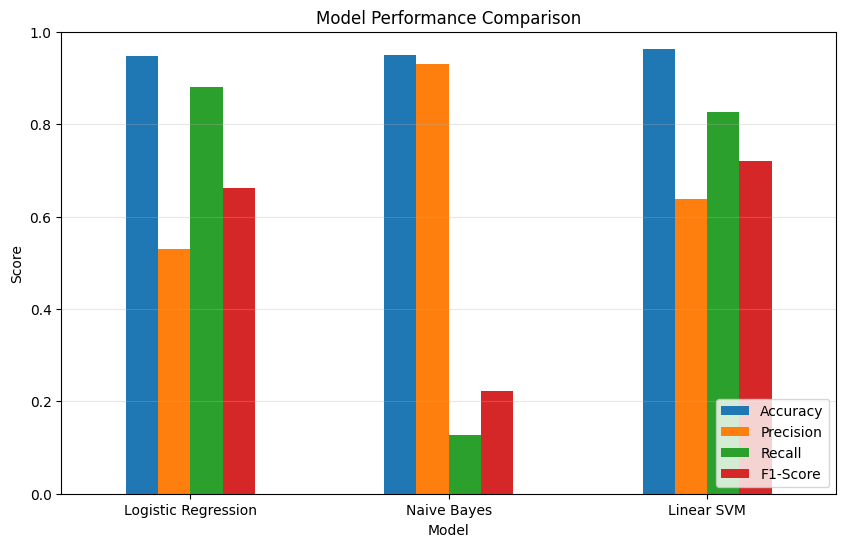

In [37]:
# Plot model performance
comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [38]:
# Identify the model with the highest F1-score
best_model_name = results_df.loc[
    results_df['F1-Score'].idxmax(),
    'Model'
]

print("Best Model based on F1-Score:", best_model_name)

Best Model based on F1-Score: Linear SVM


In [39]:
# Display detailed classification report for the best model

if best_model_name == 'Logistic Regression':
    best_predictions = y_pred_lr

elif best_model_name == 'Naive Bayes':
    best_predictions = y_pred_nb

else:
    best_predictions = y_pred_svm


print(f"Classification Report - {best_model_name}\n")
print(classification_report(y_test, best_predictions))

Classification Report - Linear SVM

              precision    recall  f1-score   support

    Negative       0.64      0.83      0.72       316
    Positive       0.99      0.97      0.98      5110

    accuracy                           0.96      5426
   macro avg       0.81      0.90      0.85      5426
weighted avg       0.97      0.96      0.96      5426



## ♦ Conclusion

In [40]:
print("Final Model Comparison")
print("**************************")

display(results_df.round(4))

print("\nBest Model based on F1-Score:", best_model_name)

Final Model Comparison
**************************


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9475,0.5295,0.8797,0.6611
1,Naive Bayes,0.9486,0.9302,0.1266,0.2228
2,Linear SVM,0.9626,0.6381,0.8259,0.7200



Best Model based on F1-Score: Linear SVM
